In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from ncmcm.data_loaders.matlab_dataset import Database
from ncmcm.bundlenet.bundlenet import BunDLeNet, train_model, model_inference
from ncmcm.bundlenet.utils import prep_data
from ncmcm.visualisers.neuronal_behavioural import plotting_neuronal_behavioural
from ncmcm.visualisers.latent_space import LatentSpaceVisualiser

2024-07-16 10:15:25.027825: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-07-16 10:15:25.053353: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-07-16 10:15:25.053395: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-07-16 10:15:25.069195: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-16 10:15:26.420782: W tensorflow/compiler/tf

## Load Data

In [3]:
rat_names = ['achilles', 'gatsby','cicero', 'buddy']
rat_name = rat_names[1]
data = np.load(f'../datasets/raw/rat_hippocampus/{rat_name}.npz')
x, b = data['x'], data['b']

## BunDLe-Net

In [4]:
x_, b_ = prep_data(x, b, win=20)

### Deploy BunDLe Net
model = BunDLeNet(latent_dim=3, num_behaviour=b_.shape[1], input_shape=x_.shape)
loss_array, _ = train_model(
    x_,
    b_,
    model,
    b_type='continuous',
    gamma=0.9,
    learning_rate=0.001,
    n_epochs=200,
    initialisation='pca_init'
)

Loss [Markov, Behaviour, Total]: [0.0042 0.0011 0.0052]: 100%|██████████| 200/200 [03:56<00:00,  1.18s/it]


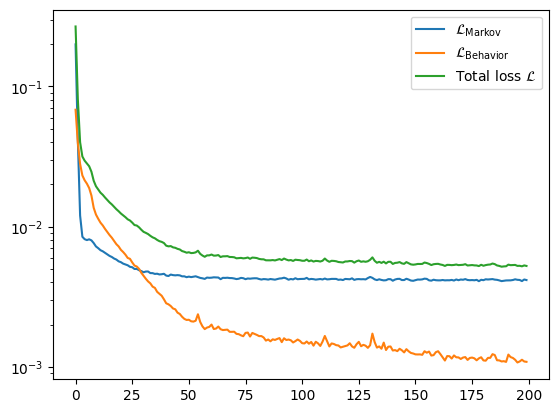

In [5]:
plt.figure()
for i, label in enumerate([
    r"$\mathcal{L}_{\mathrm{Markov}}$",
    r"$\mathcal{L}_{\mathrm{Behavior}}$",
    r"Total loss $\mathcal{L}$"
]):
    plt.semilogy(loss_array[:, i], label=label)
plt.legend()
plt.show()

## Projecting into latent space

In [6]:
y0_ = model_inference(x_, model)

## Visualising embedding

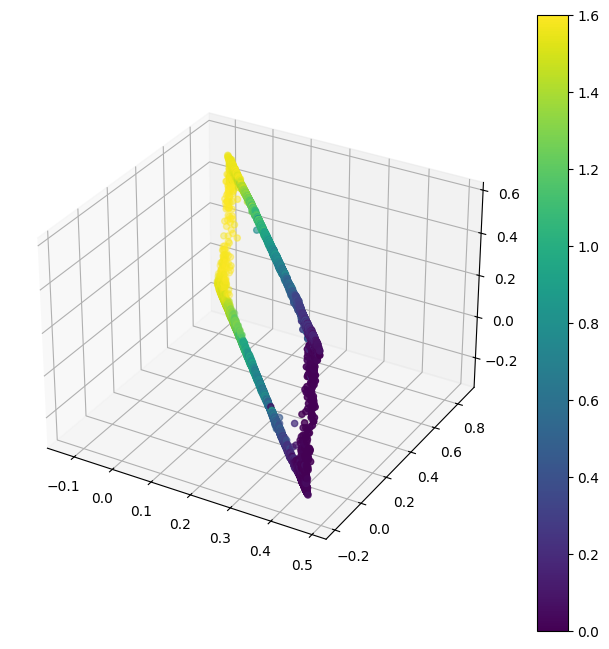

In [7]:
%matplotlib inline
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection='3d')
true_y_line = ax.scatter(y0_[:, 0], y0_[:, 1], y0_[:, 2], c=b_[:,0])
plt.colorbar(true_y_line)
plt.show()

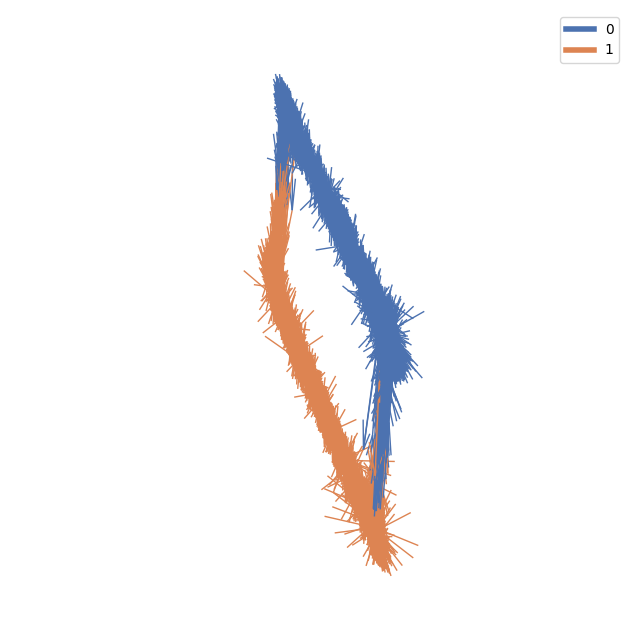

(<Figure size 800x800 with 1 Axes>, <Axes3D: >)

In [8]:
vis = LatentSpaceVisualiser(y0_, b_[:, 1].astype(int), b_names=['0', '1'])
vis.plot_phase_space()